# Turkey Business Activity — Viewer notebook

Run this end-to-end to analyze **your own** short YOLO sample from a public
Turkey camera AND compare it live to the **cloud dashboard's 24-hour history**
(pushed continuously by the admin's collector running on a GCP e2-micro).

What you get, top-to-bottom:

- Cells 1-6: pick a camera and verify the stream decodes.
- Cell 7: 1-minute local footfall time series.
- Cell 8: rolling z-score anomalies + peak-hour profile.
- Cells 9-10: dwell-time tracking (prolonged stops).
- Cells 11-14: appearance-based re-identification.
- Cell 15: "is it worth opening a business here?" — footfall + dwell + consistency.
- Cell 16: **the live cloud dashboard**, embedded inline, showing the admin's
  cumulative 24-hour view. Compare your local minute-of-samples against the day.
- Cells 17-18: rank multiple commercial sites; final summary.

**You do NOT need any Firebase credentials to run this notebook.** The dashboard
is public-read; the collector runs elsewhere.


### Network reality

The IBB streams (`livestream.ibb.gov.tr`) are public, but reachable only from an **open network** -
your own machine, a VM, or a deployed app. Restricted sandboxes (incl. the environment that generated
this repo) block those hosts via an allowlist. So **run this notebook locally**, where the streams resolve.

## 0. Setup

In [1]:
# Dependency check: verify every library the notebook needs is installed,
# install any that are missing, then print the installed versions.
# Safe to re-run - subsequent runs are just a version dump.
import importlib, subprocess, sys

# (import_name, pip_name). Pinned only where a min version matters.
REQUIREMENTS = [
    ('cv2',            'opencv-python-headless'),
    ('numpy',          'numpy'),
    ('pandas',         'pandas'),
    ('matplotlib',     'matplotlib'),
    ('PIL',            'Pillow'),
    ('ultralytics',    'ultralytics'),
    ('yt_dlp',         'yt-dlp'),
    ('firebase_admin', 'firebase-admin'),
    ('ipywidgets',     'ipywidgets>=8'),
    ('urllib3',        'urllib3'),
]

def _pip_install(spec: str) -> None:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', '-q', spec],
        stdout=sys.stdout, stderr=sys.stderr,
    )

def _version(mod) -> str:
    return getattr(mod, '__version__', getattr(mod, 'VERSION', 'unknown'))

print(f'{"import":18} {"pip package":24} status')
print('-' * 66)
missing = []
for import_name, pip_spec in REQUIREMENTS:
    try:
        m = importlib.import_module(import_name)
        print(f'{import_name:18} {pip_spec:24} OK  v{_version(m)}')
    except ImportError:
        print(f'{import_name:18} {pip_spec:24} MISSING -> installing')
        missing.append((import_name, pip_spec))

for import_name, pip_spec in missing:
    _pip_install(pip_spec)
    importlib.invalidate_caches()
    m = importlib.import_module(import_name)
    print(f'  {import_name:16} installed  v{_version(m)}')

if missing:
    print()
    print('NOTE: some packages were just installed. If the next cell errors '
          'with ModuleNotFoundError, restart the kernel (Kernel -> Restart) '
          'and re-run from the top so Python picks up the new installs.')


import             pip package              status
------------------------------------------------------------------
cv2                opencv-python-headless   OK  v4.13.0
numpy              numpy                    OK  v2.3.5
pandas             pandas                   OK  v2.3.3
matplotlib         matplotlib               OK  v3.10.6
PIL                Pillow                   OK  v12.0.0
ultralytics        ultralytics              OK  v8.4.67
yt_dlp             yt-dlp                   OK  vunknown
firebase_admin     firebase-admin           OK  v7.4.0
ipywidgets         ipywidgets>=8            OK  v8.1.7
urllib3            urllib3                  OK  v2.5.0


In [2]:
import sys, time, datetime as dt
from collections import defaultdict
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the src/ tree so the `app` package imports regardless of whether the
# notebook is run from the project root (default layout) or from inside src/.
_src_dir = Path.cwd() / 'src' if (Path.cwd() / 'src' / 'app').is_dir() else Path.cwd()
sys.path.append(str(_src_dir))
from app.detect_core import load_model, detect_and_count, grab_frame, resolve_youtube, resolve_stream, VEHICLE_NAMES
from app.cameras import CAMERAS, active_cameras, GRID_CAMERAS

DATA_DIR = _src_dir / 'data'; DATA_DIR.mkdir(parents=True, exist_ok=True)
model = load_model(str(_src_dir / 'yolov8n.pt'))
print('cameras available:', list(active_cameras()))
print('dashboard grid (4 live cameras):', GRID_CAMERAS)

cameras available: ['konya_hukumet', 'taksim', 'taksim_yeni', 'beyazit_meydan', 'kapali_carsi', 'misir_carsisi', 'sultanahmet_1', 'sultanahmet_1_yeni', 'kadikoy', 'eyup_sultan', 'uskudar', 'otogar_kavsagi', 'konya_kulturpark', 'konya_millet_caddesi', 'konya_ince_minareli', 'giresun_gazi']
dashboard grid (4 live cameras): ['konya_hukumet', 'otogar_kavsagi', 'konya_kulturpark', 'konya_millet_caddesi']


### Turkey camera catalog - open each link and see which streams work

Every camera the project can watch. Click a **name** to open its viewer page in a
new tab (it plays the live video). The **stream URL** column is the raw HLS
`.m3u8` (verified `200` at scrape time). Star marks one of the 4 cameras the cloud VM
samples into Firestore.

Because public streams rotate tokens and cycle in/out of service, verify by eye
and then answer the checkbox cell below.

| VM | ID | Name | Kind | Stream URL (HLS) |
|---|---|---|---|---|
| ★ | `konya_hukumet` | [Konya - Hukumet Meydani](https://webcamera24.com/camera/turkey/8043-sarraflar-yeralti-carsisi/) | tvkur | [c77i84vbb2nj4i0fr80g](https://content.tvkur.com/l/c77i84vbb2nj4i0fr80g/master.m3u8) |
| ★ | `otogar_kavsagi` | [Konya - Otogar Kavsagi](https://webcamera24.com/camera/turkey/8044-otogar-kavsagi/) | tvkur | [c77i91vbb2nj4i0fr81g](https://content.tvkur.com/l/c77i91vbb2nj4i0fr81g/master.m3u8) |
| ★ | `konya_kulturpark` | [Konya - Kulturpark](https://webcamera24.com/camera/turkey/8058-kulturpark/) | tvkur | [c77i6hb84cnrb6mlji3g](https://content.tvkur.com/l/c77i6hb84cnrb6mlji3g/master.m3u8) |
| ★ | `konya_millet_caddesi` | [Konya - Millet Caddesi](https://webcamera24.com/camera/turkey/8046-millet-caddesi/) | tvkur | [c77i9cfbb2nj4i0fr82g](https://content.tvkur.com/l/c77i9cfbb2nj4i0fr82g/master.m3u8) |
|  | `konya_ince_minareli` | [Konya - Ince Minareli (tram)](https://webcamera24.com/camera/turkey/8033-ince-minareli-medrese/) | tvkur | [c77ib8vbb2nj4i0fr8bg](https://content.tvkur.com/l/c77ib8vbb2nj4i0fr8bg/master.m3u8) |
|  | `giresun_gazi` | [Giresun - Gazi Caddesi](https://www.skylinewebcams.com/en/webcam/turkey/giresun/giresun/gazi-street.html) | skyline | (tokenised, page-scraped) |
|  | `ibb_anadolu_hisari` | [Istanbul - Anadolu Hisari](https://istanbuluseyret.ibb.gov.tr/anadolu-hisari-yeni/) | kamerayayin | [anadoluhisari.stream](https://kamerayayin.ibb.istanbul/turistikcam/anadoluhisari.stream/playlist.m3u8) |
|  | `ibb_beyazit_kulesi` | [Istanbul - Beyazit Kulesi 2](https://istanbuluseyret.ibb.gov.tr/beyazit-kulesi-2-yeni/) | kamerayayin | [beyazitkulesi2.stream](https://kamerayayin.ibb.istanbul/turistikcam/beyazitkulesi2.stream/playlist.m3u8) |
|  | `ibb_beyazit_meydani` | [Istanbul - Beyazit Meydani](https://istanbuluseyret.ibb.gov.tr/beyazit-meydani-yeni/) | kamerayayin | [beyazitmeydan.stream](https://kamerayayin.ibb.istanbul/turistikcam/beyazitmeydan.stream/playlist.m3u8) |
|  | `ibb_buyuk_camlica` | [Istanbul - Buyuk Camlica](https://istanbuluseyret.ibb.gov.tr/buyuk-camlica-yeni/) | kamerayayin | [buyukcamlica.stream](https://kamerayayin.ibb.istanbul/turistikcam/buyukcamlica.stream/playlist.m3u8) |
|  | `ibb_dragos` | [Istanbul - Dragos](https://istanbuluseyret.ibb.gov.tr/dragos-yeni/) | kamerayayin | [dragos.stream](https://kamerayayin.ibb.istanbul/turistikcam/dragos.stream/playlist.m3u8) |
|  | `ibb_emirgan` | [Istanbul - Emirgan](https://istanbuluseyret.ibb.gov.tr/emirgan/) | kamerayayin | [emirgan.stream](https://kamerayayin.ibb.istanbul/turistikcam/emirgan.stream/playlist.m3u8) |
|  | `ibb_eyup_sultan` | [Istanbul - Eyup Sultan](https://istanbuluseyret.ibb.gov.tr/eyup-sultan-yeni/) | kamerayayin | [eyupsultan.stream](https://kamerayayin.ibb.istanbul/turistikcam/eyupsultan.stream/playlist.m3u8) |
|  | `ibb_hidiv_kasri` | [Istanbul - Hidiv Kasri](https://istanbuluseyret.ibb.gov.tr/hidiv-kasri-yeni/) | kamerayayin | [hidivkasri.stream](https://kamerayayin.ibb.istanbul/turistikcam/hidivkasri.stream/playlist.m3u8) |
|  | `ibb_kiz_kulesi` | [Istanbul - Kiz Kulesi](https://istanbuluseyret.ibb.gov.tr/kiz-kulesi-yeni/) | kamerayayin | [kizkulesi.stream](https://kamerayayin.ibb.istanbul/turistikcam/kizkulesi.stream/playlist.m3u8) |
|  | `ibb_kucukcekmece` | [Istanbul - Kucukcekmece](https://istanbuluseyret.ibb.gov.tr/kucukcekmece-yeni/) | kamerayayin | [kucukcekmece.stream](https://kamerayayin.ibb.istanbul/turistikcam/kucukcekmece.stream/playlist.m3u8) |
|  | `ibb_pierre_lotti` | [Istanbul - Pierre Lotti](https://istanbuluseyret.ibb.gov.tr/pierre-lotti-yeni/) | kamerayayin | [pierreloti.stream](https://kamerayayin.ibb.istanbul/turistikcam/pierreloti.stream/playlist.m3u8) |
|  | `ibb_salacak` | [Istanbul - Salacak](https://istanbuluseyret.ibb.gov.tr/salacak-yeni/) | kamerayayin | [salacak.stream](https://kamerayayin.ibb.istanbul/turistikcam/salacak.stream/playlist.m3u8) |
|  | `ibb_sarachane` | [Istanbul - Sarachane](https://istanbuluseyret.ibb.gov.tr/sarachane-yeni/) | kamerayayin | [sarachane.stream](https://kamerayayin.ibb.istanbul/turistikcam/sarachane.stream/playlist.m3u8) |
|  | `ibb_sultanahmet_2` | [Istanbul - Sultanahmet 2](https://istanbuluseyret.ibb.gov.tr/sultanahmet-2-yeni/) | kamerayayin | [sultanahmet2.stream](https://kamerayayin.ibb.istanbul/turistikcam/sultanahmet2.stream/playlist.m3u8) |
|  | `ibb_taksim` | [Istanbul - Taksim](https://istanbuluseyret.ibb.gov.tr/taksim-yeni/) | kamerayayin | [taksim.stream](https://kamerayayin.ibb.istanbul/turistikcam/taksim.stream/playlist.m3u8) |
|  | `ibb_ulus_parki` | [Istanbul - Ulus Parki](https://istanbuluseyret.ibb.gov.tr/ulus-parki-yeni/) | kamerayayin | [ulusparki.stream](https://kamerayayin.ibb.istanbul/turistikcam/ulusparki.stream/playlist.m3u8) |
|  | `ibb_uskudar` | [Istanbul - Uskudar](https://istanbuluseyret.ibb.gov.tr/uskudar-yeni/) | kamerayayin | [uskudar.stream](https://kamerayayin.ibb.istanbul/turistikcam/uskudar.stream/playlist.m3u8) |

**Total:** 6 Konya/Giresun (project catalog) + 17 Istanbul IBB (all HTTP 200 at last check).


In [ ]:
# Verification: which of the recommended (VM starred) cameras did you
# actually see playing in the browser above? Tick the ones that work
# (max 4) and click Apply. This cell BLOCKS with a RuntimeError until
# you click Apply at least once, so Run All can't silently skip past it.
import ipywidgets as widgets
from IPython.display import display

RECOMMENDED = ['konya_hukumet', 'otogar_kavsagi', 'konya_kulturpark', 'konya_millet_caddesi']

# Recommended (starred) + Istanbul kamerayayin -yeni alternates. Every
# id here is a real key in src/app/cameras.py, so CAMERAS[CAM_ID] works
# for any pick. The Istanbul entries were added after the Konya tvkur
# backend went 404 on 2026-07-14 so the operator has a live fallback.
CANDIDATES = [
    ('konya_hukumet',         'Konya - Hukumet Meydani',        True),
    ('otogar_kavsagi',        'Konya - Otogar Kavsagi',         True),
    ('konya_kulturpark',      'Konya - Kulturpark',             True),
    ('konya_millet_caddesi',  'Konya - Millet Caddesi',         True),
    ('konya_ince_minareli',   'Konya - Ince Minareli (tram)',   False),
    ('taksim_yeni',           'Istanbul - Taksim',              False),
    ('sultanahmet_1_yeni',    'Istanbul - Sultanahmet',         False),
    ('beyazit_meydan_yeni',   'Istanbul - Beyazit Meydani',     False),
    ('eyup_sultan_yeni',      'Istanbul - Eyup Sultan',         False),
    ('buyuk_camlica_yeni',    'Istanbul - Buyuk Camlica',       False),
]

if 'SELECTED_CAMS_APPLIED' not in globals():
    SELECTED_CAMS_APPLIED = False
    SELECTED_CAMS = []

if '_verify_msg' not in globals():
    _verify_msg = widgets.HTML()

if '_verify_checks' not in globals():
    _verify_checks = {
        cid: widgets.Checkbox(
            value=is_reco,
            description=f'{"* " if is_reco else "  "}{cid}  -  {name}',
            indent=False,
            layout=widgets.Layout(width='auto'),
        )
        for cid, name, is_reco in CANDIDATES
    }

    def _apply(_btn=None):
        global SELECTED_CAMS, SELECTED_CAMS_APPLIED
        picked = [cid for cid, cb in _verify_checks.items() if cb.value]
        if not picked:
            _verify_msg.value = '<b style="color:#a00;">Pick at least one camera you saw working.</b>'
            return
        # Sanity: every picked id must exist in CAMERAS (fail loud rather than
        # KeyError three cells later).
        from app.cameras import CAMERAS as _CATALOG
        missing = [c for c in picked if c not in _CATALOG]
        if missing:
            _verify_msg.value = (
                f'<b style="color:#a00;">Unknown camera id(s) '
                f'not in app/cameras.py:</b> {", ".join(missing)}. '
                'Add them to the catalog or uncheck.'
            )
            return
        SELECTED_CAMS = picked[:4]
        SELECTED_CAMS_APPLIED = True
        extra = ' (kept the first 4)' if len(picked) > 4 else ''
        _verify_msg.value = (
            f'<b style="color:#080;">APPLIED - watching {len(SELECTED_CAMS)}{extra}:</b> '
            f'{", ".join(SELECTED_CAMS)}. '
            '<br><i>Now re-run this cell (or Run All below) - the block clears once APPLIED=True.</i>'
        )

    _verify_btn = widgets.Button(description='Apply selection', button_style='primary')
    _verify_btn.on_click(_apply)

    display(widgets.VBox([
        widgets.HTML(
            '<b>Recommended (starred) are the 4 the cloud VM tracks.</b><br>'
            'Tick only the ones you saw playing in the browser above (max 4), '
            'then click <b>Apply selection</b>. This cell blocks with an error '
            'below until you have clicked Apply at least once.'
        ),
        widgets.Box(list(_verify_checks.values()),
                    layout=widgets.Layout(display='flex', flex_flow='column',
                                          max_height='320px', overflow='auto',
                                          border='1px solid #ddd', padding='8px',
                                          margin='6px 0')),
        _verify_btn,
        _verify_msg,
    ]))

if not SELECTED_CAMS_APPLIED:
    raise RuntimeError(
        'Camera selection NOT APPLIED yet. Tick the cameras you saw playing '
        'above and click "Apply selection", THEN re-run this cell (or Run All). '
        'This is intentional so Run All cannot silently proceed with a default.'
    )

print(f'Selection locked in. SELECTED_CAMS = {SELECTED_CAMS}')


## 1. Pick a camera

Verified high-footfall Turkey commercial cameras live in `app/cameras.py`. Grand Bazaar, Spice Bazaar,
Taksim and Kadikoy are the densest commerce. The four cameras the live dashboard shows side by side
(`GRID_CAMERAS`) are **Konya - Hukumet Meydani**, **Giresun - Gazi Caddesi**, **Otogar Kavsagi** and
**Kadikoy**.

`resolve_stream(cam)` turns any catalog entry into an openable HLS URL regardless of `kind`:

- `hls` - used directly (IBB / tvkur).
- `youtube` - resolved via yt-dlp.
- `skyline` - Giresun: the tokenized `hd-auth.skylinewebcams.com` playlist, scraped from the page.
- `webcamera24` - Otogar Kavsagi: the embedded tvkur/YouTube player on the webcamera24 page.

The skyline and webcamera24 hosts only resolve from an **open network** (and rotate their tokens), so
run this on your own machine; in a restricted sandbox they fail like the IBB hosts.

In [ ]:
# Read the operator's first choice from the verify cell above so the
# rest of this notebook analyses whatever camera they actually picked
# (instead of a hard-coded default that ignored their choice).
CAM_ID = SELECTED_CAMS[0]
cam = CAMERAS[CAM_ID]
stream_url = resolve_stream(cam)   # handles hls / youtube / skyline / webcamera24
print(cam['name'], '->', stream_url)


## 2. Single-frame check

Confirm the stream decodes and YOLO sees the crowd before collecting anything.

In [5]:
frame = grab_frame(stream_url)
if frame is None:
    print(f"WARN: {cam['name']} returned no frame (likely geo-blocked or stream down).")
    print('Try CAM_ID = \'konya_hukumet\' (tvkur, reachable everywhere) and re-run cell 1.')
else:
    print('frame shape:', frame.shape)
    print('counts:', detect_and_count(model, frame))

    res = model.predict(frame, conf=0.35, classes=[0,1,2,3,5,7], verbose=False)[0]
    plt.figure(figsize=(11, 6))
    plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)); plt.axis('off')
    plt.title(cam['name']); plt.show()

WARN: Konya - Hukumet Meydani / Sarraflar Yeralti Carsisi returned no frame (likely geo-blocked or stream down).
Try CAM_ID = 'konya_hukumet' (tvkur, reachable everywhere) and re-run cell 1.


## 3. Footfall time series (sparse sampling)

For the **how much / when** question we don't need every frame - one sample every 15-30s is plenty and
is gentle on the server. This is the same logic the collector runs continuously.

In [6]:
def footfall_series(stream_url, cam_name, interval_s=20, duration_min=1.0):
    rows, t_end = [], time.time() + duration_min * 60
    while time.time() < t_end:
        ts = dt.datetime.now(dt.timezone.utc)
        f = grab_frame(stream_url)
        c = detect_and_count(model, f) if f is not None else {'person': np.nan, 'vehicles': np.nan}
        rows.append({'ts': ts, 'cam': cam_name, 'person': c.get('person'), 'vehicles': c.get('vehicles')})
        print(f"[{ts:%H:%M:%S}] person={c.get('person')} vehicles={c.get('vehicles')}")
        time.sleep(interval_s)
    return pd.DataFrame(rows)

# Short live-collection run. Raise duration_min for longer studies, or just leave the
# collector daemon (`python -m app.collector`) running for genuine 24/7 data.
df = footfall_series(stream_url, cam['name'], interval_s=10, duration_min=1.0)
df.to_csv(DATA_DIR / f'footfall_{CAM_ID}.csv', index=False)
df.head()

[16:40:00] person=nan vehicles=nan
[16:40:11] person=nan vehicles=nan
[16:40:21] person=nan vehicles=nan
[16:40:31] person=nan vehicles=nan
[16:40:41] person=nan vehicles=nan
[16:40:52] person=nan vehicles=nan


,ts,cam,person,vehicles
0,2026-07-14 16:40:00.961936+00:00,Konya - Hukumet Meydani / Sarraflar Yeralti Ca...,NaN,NaN
1,2026-07-14 16:40:11.171437+00:00,Konya - Hukumet Meydani / Sarraflar Yeralti Ca...,NaN,NaN
2,2026-07-14 16:40:21.382608+00:00,Konya - Hukumet Meydani / Sarraflar Yeralti Ca...,NaN,NaN
3,2026-07-14 16:40:31.590921+00:00,Konya - Hukumet Meydani / Sarraflar Yeralti Ca...,NaN,NaN
4,2026-07-14 16:40:41.816659+00:00,Konya - Hukumet Meydani / Sarraflar Yeralti Ca...,NaN,NaN


## 4. Anomalies + peak-hour profile

**Anomaly = rolling z-score > 2.5** on the footfall series: a sudden surge (event/promotion/protest) or an
unusual drop (closure/weather). Peak-hour profile tells you *when* the commercial window is.

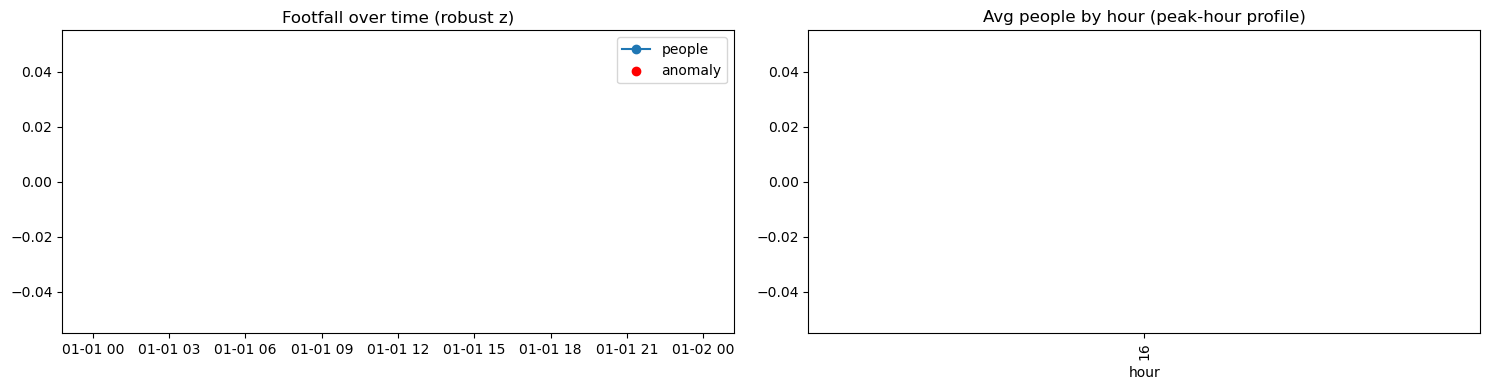

In [7]:
def flag_anomalies(s, window=12, z=3.5, min_delta=3):
    """Robust rolling z: median + MAD (x1.4826), the same statistic the cloud
    collector uses. Outliers already inside the window inflate a mean/std
    baseline and mask the next event; a median/MAD baseline barely moves."""
    med = s.rolling(window, min_periods=4).median()
    mad = (s - med).abs().rolling(window, min_periods=4).median() * 1.4826
    spread = mad.clip(lower=1.0)   # counts are integers; floor the spread
    robust_z = (s - med) / spread
    return (robust_z.abs() > z) & ((s - med).abs() >= min_delta)

df['ts'] = pd.to_datetime(df['ts'])
df['anomaly'] = flag_anomalies(df['person'])

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(df['ts'], df['person'], marker='o', label='people')
an = df[df['anomaly'] == True]
ax[0].scatter(an['ts'], an['person'], color='red', zorder=5, label='anomaly')
ax[0].set_title('Footfall over time (robust z)'); ax[0].legend()

df['hour'] = df['ts'].dt.hour
df.groupby('hour')['person'].mean().plot(kind='bar', ax=ax[1])
ax[1].set_title('Avg people by hour (peak-hour profile)')
plt.tight_layout(); plt.show()

## 5. Dwell-time / prolonged stops (tracking)

"How long does a person or vehicle stay in front of the camera?" needs **object tracking** (stable IDs
across frames), which only works on *consecutive* frames - so here we take a short **dense burst**
(a few fps for ~60s) instead of sparse sampling. Ultralytics `model.track()` (ByteTrack) gives each
object an id; we accumulate how many frames each id is seen and how little it moves.

- **Long dwell + low movement** = lingering: window-shopping / a queue / a parked vehicle.
- High share of *lingering* people is a strong **commercial-quality** signal (people stop, not just pass).

In [8]:
from app.detect_core import iter_frames, NAME_BY_ID

def dwell_analysis(stream_url, seconds=30, target_fps=3, conf=0.35):
    """Dense burst with tracking. Returns per-track dwell seconds + movement.

    iter_frames handles header-required hosts (tvkur, IBB, skylinewebcams) by
    downloading the latest segments with the right Referer/Origin and decoding
    locally, since cv2.VideoCapture(url) can't pass headers on Windows.
    """
    frames_seen = defaultdict(int)
    centroids = defaultdict(list)
    track_cls = {}
    n_frames = int(seconds * target_fps)
    for frame in iter_frames(stream_url, max_frames=n_frames):
        r = model.track(frame, persist=True, conf=conf, classes=[0,2,3,5,7],
                        tracker='bytetrack.yaml', verbose=False)[0]
        if r.boxes.id is not None:
            for box, tid, cl in zip(r.boxes.xywh.cpu().numpy(),
                                    r.boxes.id.int().cpu().tolist(),
                                    r.boxes.cls.int().cpu().tolist()):
                frames_seen[tid] += 1
                centroids[tid].append((float(box[0]), float(box[1])))
                track_cls[tid] = cl

    rows = []
    for tid, n in frames_seen.items():
        pts = np.array(centroids[tid])
        movement = float(np.linalg.norm(pts.max(0) - pts.min(0))) if len(pts) > 1 else 0.0
        rows.append({'track_id': tid,
                     'class': NAME_BY_ID.get(track_cls[tid], str(track_cls[tid])),
                     'dwell_s': round(n / target_fps, 1),
                     'movement_px': round(movement, 1)})
    return pd.DataFrame(rows).sort_values('dwell_s', ascending=False) if rows else pd.DataFrame(
        columns=['track_id','class','dwell_s','movement_px'])

dwell = dwell_analysis(stream_url, seconds=30, target_fps=3, conf=0.25)
dwell.head(15)

,track_id,class,dwell_s,movement_px


In [9]:
# Flag prolonged stationary objects: long dwell AND little movement.
PERSON_DWELL_S, VEHICLE_DWELL_S, MAX_MOVE_PX = 25, 40, 60
if not dwell.empty:
    is_person = dwell['class'] == 'person'
    stationary = dwell[((is_person & (dwell['dwell_s'] >= PERSON_DWELL_S)) |
                        (~is_person & (dwell['dwell_s'] >= VEHICLE_DWELL_S)))
                       & (dwell['movement_px'] <= MAX_MOVE_PX)]
    print(f"Prolonged stops detected: {len(stationary)}")
    display(stationary)
    linger_rate = (is_person & (dwell['dwell_s'] >= PERSON_DWELL_S)).sum() / max(1, is_person.sum())
    print(f"Linger rate (people who stayed >= {PERSON_DWELL_S}s): {linger_rate:.0%}")

## 5b. Re-identification - "have I seen this person before?"

The detection counts above tell you *how many* people are visible at any moment, but they
double-count anyone who lingers in front of the camera. To answer questions like *"how many
unique customers walked by today?"* or *"is that the same delivery van I saw yesterday?"*
we need **re-identification**: a persistent identity attached to each person/vehicle that
survives across frames, bursts and days.

The implementation is in `app/reid.py`:

1. For each YOLO detection, crop the bounding box.
2. Build a *masked* HSV color histogram (8x8x8 bins, V<30 pixels ignored - kills the
   sodium-yellow night cast on the Konya square) plus aspect ratio + normalized area.
3. L2-normalize -> 514-dim appearance vector.
4. Compare to every entity of the same class already in `data/reid.db` via cosine
   similarity. If the best match is >= `threshold` (default 0.92) we update its
   `sightings` and `last_seen`; otherwise we register a new entity.

This is a **demo-grade signature**. It works well in daylight (different clothing colors
give clearly different histograms). It produces false matches at night when the whole
scene is yellow-tinted - swap `embed_crop()` for an OSNet/torchreid forward pass for
production-grade re-ID; the SQLite registry around it stays the same.

In [ ]:
from app.detect_core import load_model, grab_frame, detect_with_boxes, annotate
from app.reid import ReidStore
import cv2, time
import matplotlib.pyplot as plt

REID_DB = str(_src_dir / 'data' / 'reid_notebook.db')
Path(REID_DB).parent.mkdir(parents=True, exist_ok=True)

# If we're re-running the notebook (the kernel is alive), the previous ReidStore is
# still holding a SQLite connection to REID_DB. Close it before we try to delete
# the file, otherwise Windows returns PermissionError [WinError 32].
try:
    reid.close()         # noqa: F821  (reid is defined by a prior run of this cell)
except NameError:
    pass

# Fresh registry for the demo so re-runs are reproducible. If something else
# still holds the file (orphan kernel, antivirus scan), we keep the existing
# rows instead of crashing - re-identification just continues with what's there.
try:
    Path(REID_DB).unlink(missing_ok=True)
    print('reid_notebook.db cleared - fresh demo registry')
except PermissionError:
    print('reid_notebook.db is locked by another process - keeping existing rows. '
          'New entities will be merged into the existing registry; this is fine '
          'for the demo, just not a clean-room run.')

reid = ReidStore(REID_DB, threshold=0.92)

# Use the model we already loaded above; lower conf so we catch the small/distant
# people the Konya wide-angle camera shows.
# CAM_ID inherits from the verify cell (SELECTED_CAMS[0]) so re-ID runs on
# the same camera as the earlier sections, not a hard-coded default.
CAM_ID = SELECTED_CAMS[0]
cam = CAMERAS[CAM_ID]
stream_url = cam['url']
print('feeding re-ID from', cam['name'])

In [11]:
# Sample N frames every `interval_s` seconds, run YOLO on each, push every detection
# through the re-ID registry. Short loop here so the notebook completes; the collector
# daemon does the real long-running version.
N_SAMPLES, INTERVAL_S, CONF = 8, 5, 0.25

rows = []
for i in range(N_SAMPLES):
    f = grab_frame(stream_url)
    if f is None:
        print(f'[{i:02d}] miss'); time.sleep(INTERVAL_S); continue
    counts, boxes = detect_with_boxes(model, f, conf=CONF)
    results = reid.update_from_frame(CAM_ID, f, boxes)
    new = sum(r.is_new for r in results)
    seen_again = len(results) - new
    rows.append({'sample': i, 'person': counts['person'], 'vehicles': counts['vehicles'],
                 'detections': len(boxes), 'new_ids': new, 'seen_again': seen_again})
    print(f'[{i:02d}] person={counts["person"]} vehicles={counts["vehicles"]} '
          f'-> new={new} seen_again={seen_again}')
    time.sleep(INTERVAL_S)

reid_df = pd.DataFrame(rows)
reid_df

[00] miss
[01] miss
[02] miss
[03] miss
[04] miss
[05] miss
[06] miss
[07] miss


""


In [12]:
# Roll-up: how many unique entities did we see? how many came back >=3 times?
stats = reid.stats(CAM_ID)
print('Total unique entities (this camera):', stats['total_unique'])
print('Total sightings:', stats['total_sightings'])
for cls, s in stats['per_class'].items():
    print(f"  {cls:10s}  unique={s['unique']}  sightings={s['total_sightings']}  "
          f"regulars(>=3)={s['regulars']}")

print('\nTop returning entities:')
for r in reid.top_regulars(CAM_ID, n=10):
    print(f"  #{r['entity_id']:4d}  {r['cls']:8s}  sightings={r['sightings']}  "
          f"first={r['first_seen']}  last={r['last_seen']}")

Total unique entities (this camera): 0
Total sightings: 0

Top returning entities:


In [13]:
# Visual: returning-visitor curve - what fraction of detections are 'seen again' over time?
if len(reid_df) >= 3:
    reid_df = reid_df.copy()
    reid_df['returning_rate'] = (reid_df['seen_again'] /
                                 reid_df['detections'].replace(0, np.nan))
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(reid_df['sample'], reid_df['new_ids'], marker='o', label='new IDs')
    ax[0].plot(reid_df['sample'], reid_df['seen_again'], marker='s', label='seen again')
    ax[0].set_title('Re-ID activity per sample')
    ax[0].set_xlabel('sample #'); ax[0].set_ylabel('count'); ax[0].legend()

    ax[1].plot(reid_df['sample'], reid_df['returning_rate'].fillna(0), marker='o',
               color='#36d399')
    ax[1].set_title('Returning-visitor rate (seen_again / detections)')
    ax[1].set_xlabel('sample #'); ax[1].set_ylim(0, 1)
    plt.tight_layout(); plt.show()
else:
    print('Not enough samples for the returning-visitor plot.')

Not enough samples for the returning-visitor plot.


IMPORTANT - re-ID quality depends on the scene.
#
At Konya Hukumet Meydani at night the whole scene is uniform sodium yellow.
Color-histogram re-ID will over-merge IDs there. To validate the *concept*, point
the camera at the daylight Grand Bazaar / Spice Bazaar (different clothing colors)
or set `threshold=0.97` to be very conservative about matches.
#
Production path:
  pip install torchreid
  from torchreid.utils import FeatureExtractor
  extractor = FeatureExtractor(model_name='osnet_ain_x1_0', model_path='', device='cpu')
  def embed_crop(crop, cls): return extractor([crop])[0].cpu().numpy()
Then keep the rest of app/reid.py exactly as-is. The 2,048-dim OSNet embedding
survives lighting changes, pose changes, and partial occlusion much better than
a color histogram.

## 6. "Is it worth opening a business here?" - a simple score

Combine three signals into one 0-100 score. Tune the weights to your business type (a cafe wants high
*linger*; a kiosk wants high *throughput*).

- **Volume** - median footfall (raw demand).
- **Linger** - share of people who stop (engagement / conversion potential).
- **Consistency** - low coefficient of variation (steady traffic beats spiky).

In [14]:
def business_score(footfall_df, dwell_df, w=(0.5, 0.3, 0.2)):
    people = footfall_df['person'].dropna()
    volume = float(people.median()) if len(people) else 0.0
    cv = float(people.std() / people.mean()) if people.mean() else 1.0
    consistency = max(0.0, 1 - cv)
    is_p = dwell_df['class'] == 'person'
    linger = float((is_p & (dwell_df['dwell_s'] >= 25)).sum() / max(1, is_p.sum())) if len(dwell_df) else 0.0
    vol_norm = min(1.0, volume / 40.0)  # ~40 people/frame treated as 'very busy'; tune per camera FOV
    score = 100 * (w[0]*vol_norm + w[1]*linger + w[2]*consistency)
    return {'volume_median': round(volume,1), 'linger_rate': round(linger,2),
            'consistency': round(consistency,2), 'score_0_100': round(score,1)}

print(cam['name'])
business_score(df, dwell)

Konya - Hukumet Meydani / Sarraflar Yeralti Carsisi


{'volume_median': 0.0,
 'linger_rate': 0.0,
 'consistency': 0.0,
 'score_0_100': 0.0}

## 7. Compare with the live cloud dashboard

The rest of this notebook was your **local** analysis — a minute of sampling on
one camera. The cloud collector has been running non-stop on a GCP VM,
accumulating 4 cameras × 24 hours into Firestore, and the HTML dashboard below
subscribes to that. Comparing the two answers real questions:

- Is the moment I sampled representative of the whole day? (my minute vs the 24h chart)
- Am I hitting a peak, a valley, or the average?
- Did any anomaly fire in the last 24 hours that I missed by sampling now?

Nothing here writes to Firestore — it's a plain HTML page that reads from it.


In [15]:
# Serve web/ locally on http://localhost:8000 and embed the live dashboard.
# The dashboard reads directly from Firestore (public-read) — no credentials
# needed. The tvkur HLS proxy lets the Konya tiles autoplay.
import sys, threading, http.server, webbrowser
from app.dashboard_server import DashboardHandler, WEB_DIR, port_is_free

DASHBOARD_PORT = 8000
_main = sys.modules['__main__']

if getattr(_main, '_dash_server', None) is None:
    if not port_is_free(DASHBOARD_PORT):
        print(f'Port {DASHBOARD_PORT} already in use — assuming a dashboard is up. '
              f'Open http://localhost:{DASHBOARD_PORT}/')
        _main._dash_server = 'external'
    else:
        factory = lambda *a, **k: DashboardHandler(*a, directory=str(WEB_DIR), **k)
        http.server.ThreadingHTTPServer.allow_reuse_address = True
        http.server.ThreadingHTTPServer.daemon_threads      = True
        srv = http.server.ThreadingHTTPServer(('', DASHBOARD_PORT), factory)
        threading.Thread(target=srv.serve_forever, daemon=True).start()
        _main._dash_server = srv
        print(f'Dashboard server started at http://localhost:{DASHBOARD_PORT}/')

dash_url = f'http://localhost:{DASHBOARD_PORT}/'
if not getattr(_main, '_dash_browser_opened', False):
    try:    webbrowser.open(dash_url, new=2)
    except: pass
    _main._dash_browser_opened = True

from IPython.display import display, HTML, IFrame
display(HTML(f'<p><b>Live dashboard (cloud collector, 24h TTL):</b> '
             f'<a href="{dash_url}" target="_blank">{dash_url}</a></p>'))
display(IFrame(dash_url, width='100%', height=640))


Dashboard server started at http://localhost:8000/


  "GET / HTTP/1.1" 200 -
  "GET /firebase-config.js?v=40 HTTP/1.1" 200 -
  "GET /app.js?v=40 HTTP/1.1" 200 -
  "GET /cameras.js?v=40 HTTP/1.1" 200 -
  "GET /api/review-stats HTTP/1.1" 200 -
  "GET /api/review-frames-stats HTTP/1.1" 200 -
  "GET /api/review-frames-list HTTP/1.1" 200 -
  "GET /api/boost-status HTTP/1.1" 200 -
  "GET /api/model-metrics HTTP/1.1" 200 -
  "GET /api/review-frame HTTP/1.1" 200 -
  "GET /tvkur/c77i84vbb2nj4i0fr80g/master.m3u8 HTTP/1.1" 502 -
  "GET /api/anomaly-crops-stats HTTP/1.1" 200 -
  "GET /snapshots/review_frames/konya_hukumet/1783763198890849.jpg HTTP/1.1" 200 -
  "GET /tvkur/c77i6hb84cnrb6mlji3g/master.m3u8 HTTP/1.1" 502 -
  "GET /tvkur/c77i91vbb2nj4i0fr81g/master.m3u8 HTTP/1.1" 502 -
  "GET /tvkur/c77i9cfbb2nj4i0fr82g/master.m3u8 HTTP/1.1" 502 -
  "GET /api/live-samples-stats HTTP/1.1" 200 -
  "GET /tvkur/c77i9cfbb2nj4i0fr82g/master.m3u8 HTTP/1.1" 502 -
  "GET /tvkur/c77i84vbb2nj4i0fr80g/master.m3u8 HTTP/1.1" 502 -
  "GET /tvkur/c77i91vbb2nj4i0fr81g/

## 8. Compare multiple commercial sites

Loop the footfall sampler over several cameras to rank locations by activity - the input to a
site-selection decision.

In [ ]:
# Rank the cameras YOU picked in verify7cams above (SELECTED_CAMS) by
# activity. This is a LOCAL analysis - it uses your dynamic pick, not
# the fixed VM grid. Cameras that can't resolve or return no frames are
# skipped, so if some picks are down you still get a partial ranking.
summary = []
for cid in SELECTED_CAMS:
    c = CAMERAS.get(cid)
    if not c or not c.get('url'):
        print(f'{cid}: skipped (not in catalog or no url)')
        continue
    try:
        url = resolve_stream(c)
    except Exception as e:
        print(f'{cid}: resolve failed ({e})')
        continue
    # one quick decode check before spending 30s on this camera
    if grab_frame(url) is None:
        print(f'{cid}: no frame from stream (geo-blocked / down). Skipping.')
        continue
    sdf = footfall_series(url, c['name'], interval_s=10, duration_min=0.5)
    summary.append({'site': c['name'],
                    'median_people': sdf['person'].median(),
                    'max_people': sdf['person'].max()})

if summary:
    pd.DataFrame(summary).sort_values('median_people', ascending=False)
else:
    print('No camera in SELECTED_CAMS produced usable frames - nothing to rank.')


## 9. Live summary - what did we find?

Pulls everything the notebook saw on this run into a single block: the anomalies
flagged across every sampled camera, the re-ID totals, and a tiny visualisation
plotting all anomalies on the same timeline. Re-running the notebook regenerates
this from scratch - no stale timestamps from someone else's session leak through.

In [ ]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    from datetime import datetime, timezone

    print(f"Notebook run finished at {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')} UTC")
    print(f"Live camera for this run: {cam['name']}")
    print("=" * 78)

    # ---- aggregate anomalies into one DataFrame ----
    anom_frames = []
    if "df" in dir() and isinstance(df, pd.DataFrame) and not df.empty and "anomaly" in df.columns:
        a = df[df["anomaly"] == True].copy()
        if not a.empty:
            a["cam"] = cam["name"]
            anom_frames.append(a[["ts", "cam", "person", "vehicles"]])
    anom = pd.concat(anom_frames, ignore_index=True) if anom_frames else \
           pd.DataFrame(columns=["ts", "cam", "person", "vehicles"])

    if len(anom):
        print(f"\nAnomalies flagged (rolling z > 2.5): {len(anom)}")
        print(anom.to_string(index=False))
    else:
        print("\nAnomalies flagged: 0")
        print("(Too few samples for the z-score window to trip, or the scene was steady.)")

    # ---- re-ID rollup ----
    if "reid" in dir():
        stats = reid.stats(CAM_ID)
        print("\n" + "-" * 78)
        print(f"Re-identification - {cam['name']}")
        print(f"  total unique entities   : {stats['total_unique']}")
        print(f"  total sightings         : {stats['total_sightings']}")
        for cls, s in stats["per_class"].items():
            print(f"    {cls:10s}  unique={s['unique']}  "
                  f"sightings={s['total_sightings']}  "
                  f"regulars(>=3)={s['regulars']}")
        regulars = reid.top_regulars(CAM_ID, n=5)
        if regulars:
            print("  top returning:")
            for r in regulars:
                print(f"    #{r['entity_id']:>4}  {r['cls']:8s}  "
                      f"sightings={r['sightings']}  last_seen={r['last_seen']}")

    # ---- always-on visual: footfall over this run + anomalies overlaid ----
    # Build the plot only when we have data; do NOT call ax.legend() on an empty
    # axes (that produces the "No artists with labels found" warning).
    if "df" in dir() and isinstance(df, pd.DataFrame) and not df.empty:
        ts = pd.to_datetime(df["ts"])
        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(ts, df["person"],   marker="o", color="#4f8cff", label="people")
        ax.plot(ts, df["vehicles"], marker="s", color="#f0a35e", label="vehicles", alpha=0.85)
        if len(anom):
            ax.scatter(pd.to_datetime(anom["ts"]), anom["person"],
                       s=160, color="#ef4444", marker="X", zorder=5, label="anomaly")
        ax.set_title(f"This run: {cam['name']}  ({len(df)} samples, {len(anom)} anomalies)")
        ax.set_ylabel("count per frame"); ax.set_xlabel("timestamp (UTC)")
        ax.legend(loc="upper left"); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    print("\n" + "=" * 78)
    print("For the persistent shared HTML dashboard (Firestore-backed):")
    print("  collector  : run the cell in Section 7 of this notebook,")
    print("               or `python -m app.collector --interval 20 --only "
          "konya_hukumet,otogar_kavsagi,konya_kulturpark,konya_millet_caddesi`")
    print("  dashboard  : python serve.py        (from the project root)")
    print("  open       : http://localhost:8000  (opens automatically)")

except Exception as e:
    print(f"summary cell stopped early: {type(e).__name__}: {e}")


## 10. Accuracy calibration - how good are the counts, really?

The dashboard is only as trustworthy as YOLO is on THESE cameras. This section
measures it: capture frames from the 4 live grid cameras, run the detector at
two input sizes (640 = old default, 960 = the collector's current default),
then count people/vehicles yourself and get MAE + bias per camera and per size.

Workflow (all local, ~10 minutes of counting):
1. **10a** captures frames + predictions into `data/calibration/`;
2. **10b** shows each frame - you type the true `people,vehicles`;
3. **10c** prints the accuracy table and a conf/imgsz recommendation.

Feed the result back into the pipeline: the winning `imgsz` goes to the
collector's `--imgsz`, and a camera with a systematic bias gets a `"conf"`
override in `app/cameras.py` (bias < 0 -> lower conf, bias > 0 -> raise it).

In [ ]:
# --- 10a. Capture calibration frames + predictions (run once, ~1-2 min) ---
import json as _json
from app.detect_core import grab_burst, detect_with_boxes, annotate

CALIB_DIR = DATA_DIR / 'calibration'; CALIB_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_PER_CAM = 6          # 4 cams x 6 frames = 24 to label (aim for 20-30)
IMG_SIZES = (640, 960)      # old default vs the collector's current default
CALIB_CONF = 0.30           # keep in sync with the collector's --conf

samples = []
for cam_id in GRID_CAMERAS:
    cam = CAMERAS[cam_id]
    try:
        url = resolve_stream(cam)
    except Exception as e:
        print(f'{cam_id}: resolve failed ({e}) - skipping'); continue
    got = 0
    for k in range(FRAMES_PER_CAM):
        frames = grab_burst(url, n=1)
        if not frames:
            print(f'{cam_id}: frame {k} MISS'); continue
        frame = frames[0]
        stem = f'{cam_id}_{k:02d}'
        cv2.imwrite(str(CALIB_DIR / f'{stem}.jpg'), frame)
        entry = {'stem': stem, 'cam_id': cam_id}
        for size in IMG_SIZES:
            counts, _ = detect_with_boxes(model, frame, conf=CALIB_CONF, imgsz=size)
            entry[f'person_{size}']   = counts['person']
            entry[f'vehicles_{size}'] = counts['vehicles']
        cv2.imwrite(str(CALIB_DIR / f'{stem}_annotated.jpg'),
                    annotate(model, frame, conf=CALIB_CONF, imgsz=max(IMG_SIZES)))
        samples.append(entry); got += 1
        time.sleep(2)   # let the live stream move on a little between captures
    print(f'{cam_id}: captured {got} frames')

(CALIB_DIR / 'predictions.json').write_text(_json.dumps(samples, indent=2))
print(f'{len(samples)} frames -> {CALIB_DIR}')

In [ ]:
# --- 10b. Label: look at each frame, type the true counts ---
# The annotated image shows what the model saw at imgsz=960. Count what YOU
# see: people, then vehicles (cars+buses+trucks+motorbikes+bicycles), and type
# `people,vehicles` (e.g. `7,3`). Enter = skip frame, q = stop early.
import json as _json

samples = _json.loads((CALIB_DIR / 'predictions.json').read_text())
labeled = []
for s in samples:
    img = cv2.cvtColor(cv2.imread(str(CALIB_DIR / f"{s['stem']}_annotated.jpg")),
                       cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 7)); plt.imshow(img); plt.axis('off')
    plt.title(f"{s['stem']}  |  model@960: person={s['person_960']} "
              f"vehicles={s['vehicles_960']}")
    plt.show()
    raw = input(f"{s['stem']} true 'people,vehicles' (Enter=skip, q=stop): ").strip()
    if raw.lower() == 'q':
        break
    if not raw:
        continue
    try:
        p_true, v_true = (int(x) for x in raw.replace(' ', '').split(','))
    except ValueError:
        print('  could not parse - skipped'); continue
    labeled.append({**s, 'person_true': p_true, 'vehicles_true': v_true})

(CALIB_DIR / 'labeled.json').write_text(_json.dumps(labeled, indent=2))
print(f'labeled {len(labeled)} frames -> {CALIB_DIR / "labeled.json"}')

In [ ]:
# --- 10c. Accuracy report: MAE + bias per input size and per camera ---
import json as _json

rows = _json.loads((CALIB_DIR / 'labeled.json').read_text())
assert rows, 'No labeled frames yet - run 10b first.'
cal = pd.DataFrame(rows)

overall = []
for size in IMG_SIZES:
    for metric in ('person', 'vehicles'):
        err = cal[f'{metric}_{size}'] - cal[f'{metric}_true']
        overall.append({'imgsz': size, 'metric': metric,
                        'MAE': round(err.abs().mean(), 2),
                        'bias': round(err.mean(), 2),   # negative = undercount
                        'n': len(cal)})
print('=== overall (all cameras) ===')
print(pd.DataFrame(overall).to_string(index=False))

best = max(IMG_SIZES)
per_cam = []
for cam_id, g in cal.groupby('cam_id'):
    for metric in ('person', 'vehicles'):
        err = g[f'{metric}_{best}'] - g[f'{metric}_true']
        per_cam.append({'cam': cam_id, 'metric': metric,
                        'MAE': round(err.abs().mean(), 2),
                        'bias': round(err.mean(), 2), 'n': len(g)})
print(f'=== per camera @ imgsz={best} ===')
print(pd.DataFrame(per_cam).to_string(index=False))

print("""
How to read this:
- bias < 0 -> systematic undercount: lower that camera's conf (add e.g.
  "conf": 0.25 to its entry in app/cameras.py). bias > 0 -> overcount: raise it.
- If MAE@960 < MAE@640 (typical for these wide shots), keep the collector's
  default --imgsz 960; otherwise fall back to 640.
- Re-run this section after any camera swap or weights change.""")